In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 12

taus = [500, 2000]

time_axis = np.arange(0, 10000, 1)

def exp_prob(time_axis : np.ndarray, tau : float):
    """
    Probability of a photon for each of a set of time values
    given a tau exponential lifetime
    """
    return np.exp(-time_axis / tau) / tau

## Probability of emitting a photon vs. just visualizing the exponential

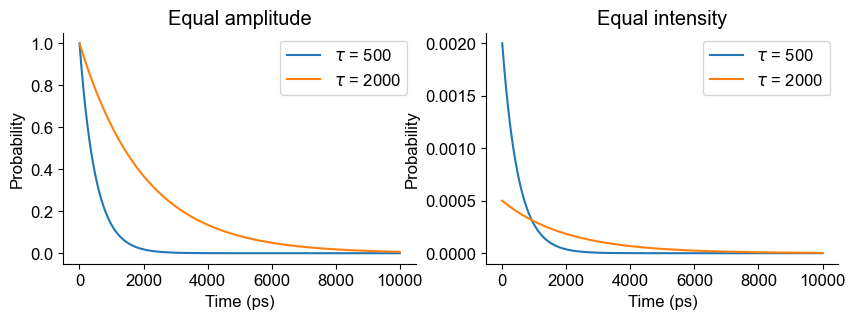

In [2]:
histograms_f, histograms_plt = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

histograms_plt[0].set_title("Equal amplitude")
histograms_plt[1].set_title("Equal intensity")

for idx, tau in enumerate(taus):
    histograms_plt[0].plot(
        time_axis,
        exp_prob(time_axis, tau)*tau,
        label=fr"$\tau$ = {tau}"
    )

    histograms_plt[1].plot(
        time_axis,
        exp_prob(time_axis, tau),
        label=fr"$\tau$ = {tau}",
    )

for x in histograms_plt:
    x.set_xlabel("Time (ps)")
    x.set_ylabel("Probability")
    x.spines["top"].set_visible(False)
    x.spines["right"].set_visible(False)
    x.legend()


## Modeling the case that both fluorophores emit with equal brightness

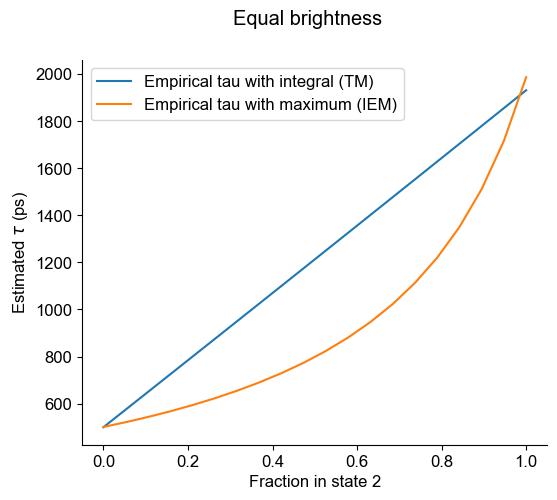

In [3]:
intensity_1 = np.linspace(0,1,20,endpoint = True)

# ratio of state 1 to state 2
relative_brightness = 1 

combined = (
        intensity_1.reshape(-1,1) @ exp_prob(time_axis, taus[0]).reshape(1,-1) +
        (1-intensity_1).reshape(-1,1) @ exp_prob(time_axis, taus[1]).reshape(1,-1)
)

tm = np.sum(time_axis * combined, axis=1) / np.sum(combined, axis=1)
iem = np.sum(combined, axis=1)/np.max(combined,axis=1)


estimates_f, estimates_plt = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))

estimates_f.suptitle('Equal brightness')

estimates_plt.plot(
    1-intensity_1,
    tm,
    label = 'Empirical tau with integral (TM)'
)

estimates_plt.plot(
    1-intensity_1,
    iem,
    label = 'Empirical tau with maximum (IEM)'
)

estimates_plt.set_xlabel("Fraction in state 2")
estimates_plt.set_ylabel(fr"Estimated $\tau$ (ps)")
estimates_plt.legend()

estimates_plt.spines["top"].set_visible(False)
estimates_plt.spines["right"].set_visible(False)


## Unequal brightness

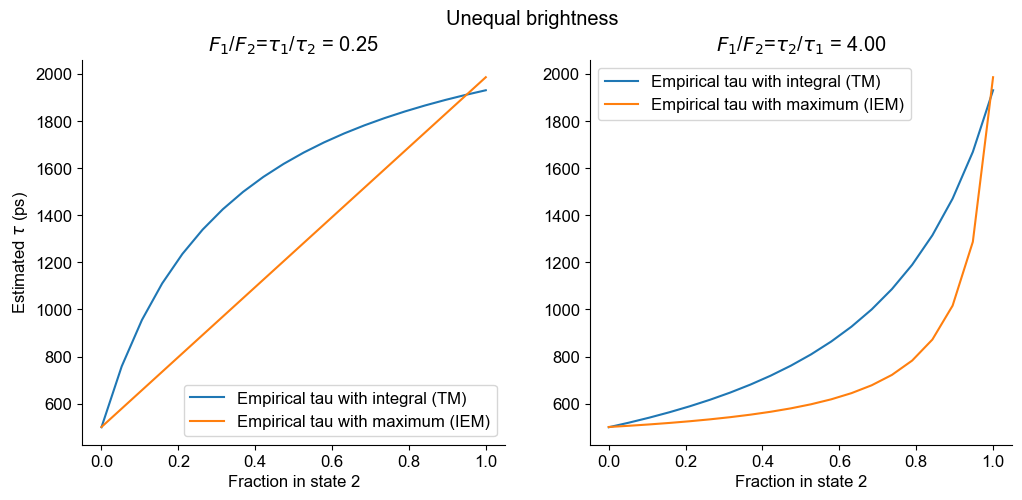

In [4]:
fraction_1 = np.linspace(0,1,20,endpoint = True)

# ratio of state 1 to state 2
relative_brightness = taus[0]/taus[1]

combined = (
        relative_brightness*fraction_1.reshape(-1,1) @ exp_prob(time_axis, taus[0]).reshape(1,-1) +
        (1-fraction_1).reshape(-1,1) @ exp_prob(time_axis, taus[1]).reshape(1,-1)
)

tm = np.sum(time_axis * combined, axis=1) / np.sum(combined, axis=1)
iem = np.sum(combined, axis=1)/np.max(combined,axis=1)

estimates_f, estimates_plt = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

estimates_f.suptitle(fr'Unequal brightness')

estimates_plt[0].set_title(fr'$F_1$/$F_2$=$\tau_1$/$\tau_2$ = {relative_brightness:.2f}')

estimates_plt[0].plot(
    1-fraction_1,
    tm,
    label = 'Empirical tau with integral (TM)'
)

estimates_plt[0].plot(
    1-fraction_1,
    iem,
    label = 'Empirical tau with maximum (IEM)'
)

estimates_plt[0].set_xlabel("Fraction in state 2")
estimates_plt[0].legend()

estimates_plt[1].set_title(fr'$F_1$/$F_2$=$\tau_2$/$\tau_1$ = {1.0/relative_brightness:.2f}')

combined = (
        (1.0/relative_brightness)*fraction_1.reshape(-1,1) @ exp_prob(time_axis, taus[0]).reshape(1,-1) +
        (1-fraction_1).reshape(-1,1) @ exp_prob(time_axis, taus[1]).reshape(1,-1)
)

tm = np.sum(time_axis * combined, axis=1) / np.sum(combined, axis=1)
iem = np.sum(combined, axis=1)/np.max(combined,axis=1)

estimates_plt[1].plot(
    1-fraction_1,
    tm,
    label = 'Empirical tau with integral (TM)'
)

estimates_plt[1].plot(
    1-fraction_1,
    iem,
    label = 'Empirical tau with maximum (IEM)'
)

estimates_plt[1].set_xlabel("Fraction in state 2")
estimates_plt[1].legend()

estimates_plt[0].set_ylabel(fr"Estimated $\tau$ (ps)")

for x in estimates_plt:
    x.spines["top"].set_visible(False)
    x.spines["right"].set_visible(False)


If we do the same analysis, now for many possible ratios, we can see that both exhibit nonlinearities, but the IEM distorts more slowly when $\tau_1/\tau_2$ is near $F_1/F2$

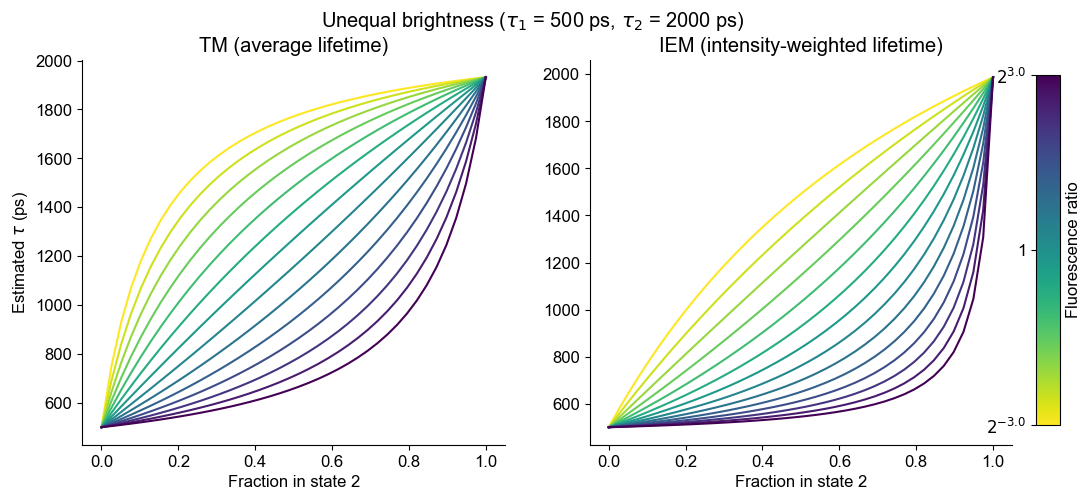

In [5]:
fluorescence_ratios = np.logspace(-3, 3, 14, base = 2, endpoint=True)

estimates_f, estimates_plt = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

estimates_f.suptitle(fr'Unequal brightness ($\tau_1$ = {taus[0]} ps, $\tau_2$ = {taus[1]} ps)')

for x in estimates_plt.flatten():
    x.spines["top"].set_visible(False)
    x.spines["right"].set_visible(False)

tm_plt, iem_plt = estimates_plt

from matplotlib import colormaps
from matplotlib.colors import Normalize

cmap = colormaps.get_cmap('viridis_r')
norm = Normalize(vmin=np.log2(np.min(fluorescence_ratios)), vmax=np.log2(np.max(fluorescence_ratios)))

tm_plt.set_title('TM (average lifetime)')
tm_plt.set_xlabel("Fraction in state 2")
iem_plt.set_title('IEM (intensity-weighted lifetime)')
iem_plt.set_xlabel("Fraction in state 2")

fraction_1 = np.linspace(0,1,40,endpoint = True)

tm_plt.set_ylabel(fr"Estimated $\tau$ (ps)")

for ratio in fluorescence_ratios:
    combined = (
        ratio*fraction_1.reshape(-1,1) @ exp_prob(time_axis, taus[0]).reshape(1,-1) +
        (1-fraction_1).reshape(-1,1) @ exp_prob(time_axis, taus[1]).reshape(1,-1)
    )

    tm = np.sum(time_axis * combined, axis=1) / np.sum(combined, axis=1)
    iem = np.sum(combined, axis=1)/np.max(combined,axis=1)

    tm_plt.plot(
        1-fraction_1,
        tm,
        color = cmap(norm(np.log2(ratio))),
    )

    iem_plt.plot(
        1-fraction_1,
        iem,
        color = cmap(norm(np.log2(ratio))),
    )

from matplotlib.colorbar import ColorbarBase

cbar = ColorbarBase(
    ax=estimates_f.add_axes([0.92, 0.15, 0.02, 0.7]),
    cmap=cmap,
    norm=norm,
    orientation='vertical',
    label='Fluorescence ratio'
)

# Ticks at the min, 0, and max
tick_vals = np.log2(fluorescence_ratios[0]), 0, np.log2(fluorescence_ratios[-1])

cbar.set_ticks(tick_vals)

ticklabels = [r'$2^{' + f'{tick_vals[0]:.1f}' + r'}$']
ticklabels += [1]
ticklabels += [r'$2^{' + f'{tick_vals[-1]:.1f}' + r'}$']

cbar.set_ticklabels(
    ticklabels
)

cbar.ax.yaxis.set_ticks_position('left')

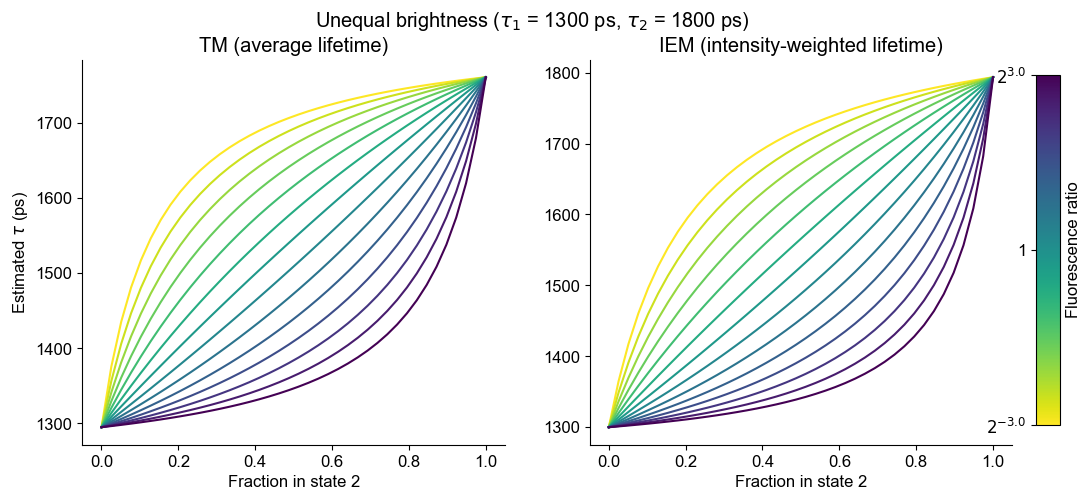

In [6]:
taus_two = [1300, 1800]

estimates_f, estimates_plt = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

estimates_f.suptitle(fr'Unequal brightness ($\tau_1$ = {taus_two[0]} ps, $\tau_2$ = {taus_two[1]} ps)')

for x in estimates_plt.flatten():
    x.spines["top"].set_visible(False)
    x.spines["right"].set_visible(False)

tm_plt, iem_plt = estimates_plt

from matplotlib import colormaps
from matplotlib.colors import Normalize

cmap = colormaps.get_cmap('viridis_r')
norm = Normalize(vmin=np.log2(np.min(fluorescence_ratios)), vmax=np.log2(np.max(fluorescence_ratios)))

tm_plt.set_title('TM (average lifetime)')
tm_plt.set_xlabel("Fraction in state 2")
iem_plt.set_title('IEM (intensity-weighted lifetime)')
iem_plt.set_xlabel("Fraction in state 2")

fraction_1 = np.linspace(0,1,40,endpoint = True)

tm_plt.set_ylabel(fr"Estimated $\tau$ (ps)")

for ratio in fluorescence_ratios:
    combined = (
        ratio*fraction_1.reshape(-1,1) @ exp_prob(time_axis, taus_two[0]).reshape(1,-1) +
        (1-fraction_1).reshape(-1,1) @ exp_prob(time_axis, taus_two[1]).reshape(1,-1)
    )

    tm = np.sum(time_axis * combined, axis=1) / np.sum(combined, axis=1)
    iem = np.sum(combined, axis=1)/np.max(combined,axis=1)

    tm_plt.plot(
        1-fraction_1,
        tm,
        color = cmap(norm(np.log2(ratio))),
    )

    iem_plt.plot(
        1-fraction_1,
        iem,
        color = cmap(norm(np.log2(ratio))),
    )

from matplotlib.colorbar import ColorbarBase

cbar = ColorbarBase(
    ax=estimates_f.add_axes([0.92, 0.15, 0.02, 0.7]),
    cmap=cmap,
    norm=norm,
    orientation='vertical',
    label='Fluorescence ratio'
)

# Ticks at the min, 0, and max
tick_vals = np.log2(fluorescence_ratios[0]), 0, np.log2(fluorescence_ratios[-1])

cbar.set_ticks(tick_vals)

ticklabels = [r'$2^{' + f'{tick_vals[0]:.1f}' + r'}$']
ticklabels += [1]
ticklabels += [r'$2^{' + f'{tick_vals[-1]:.1f}' + r'}$']

cbar.set_ticklabels(
    ticklabels
)

cbar.ax.yaxis.set_ticks_position('left')

cbar.ax.yaxis.set_ticks_position('left')